In [307]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def carregar_titanic_dataset():
    caminho_arquivo = Path('datasets/titanic.tgz')
    if not caminho_arquivo.is_file():
        Path('datasets').mkdir(parents=True, exist_ok=True)
        url = 'https://homl.info/titanic.tgz'
        urllib.request.urlretrieve(url, caminho_arquivo)
        with tarfile.open(caminho_arquivo) as titanic_tarball:
            titanic_tarball.extractall(path='datasets', filter='data')
        
    treino = pd.read_csv(Path("datasets/titanic/train.csv"))
    teste = pd.read_csv(Path("datasets/titanic/test.csv"))
    return treino, teste

In [308]:
titanic_treino, titanic_teste = carregar_titanic_dataset()
titanic_treino.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


## Primeiras Impressões ##

Idade e Cabine possuem valores nulos

In [309]:
titanic_treino.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Há mais pessoas de primeira classe do que de segunda

In [310]:
titanic_treino['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Há mais homens que mulheres

In [311]:
titanic_treino['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

A maioria dos passeiros estavam desacompanhados

In [312]:
#Irmãos e esposas
print(titanic_treino['SibSp'].value_counts())
print(f'Percentual de passageiros sem irmão e/ou esposas: {(titanic_treino['SibSp']==0).astype(int).sum()/len(titanic_treino['SibSp']):.1%}')

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64
Percentual de passageiros sem irmão e/ou esposas: 68.2%


In [313]:
#Pais e Filhos
print(titanic_treino['Parch'].value_counts())
print(f'Percentual de passageiros sem pais e/ou filhos: {(titanic_treino['Parch']==0).astype(int).sum()/len(titanic_treino['Parch']):.1%}')

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64
Percentual de passageiros sem pais e/ou filhos: 76.1%


In [314]:
#Local do Embarque
titanic_treino["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Podemos extrair a informação alfabética da cabine

In [315]:
print(titanic_treino['Cabin'].value_counts()[:8])
titanic_treino["Cabin"].str[0].value_counts()

Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F2             3
D              3
E101           3
C22 C26        3
F33            3
Name: count, dtype: int64


Cabin
C    59
B    47
D    33
E    32
A    15
F    13
G     4
T     1
Name: count, dtype: int64

Para os valores nulos de idade, pode-se usar a média global de idade ou uma média de idade por grupo de interesse.

In [316]:
titanic_treino['Age'].describe()

count    714.000000
mean      29.699113
std       14.526507
min        0.416700
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [317]:
titanic_treino.groupby(["Sex","Pclass"])["Age"].describe()

count       mean        std     min     25%   50%    75%   max
Sex    Pclass                                                                
female 1        85.0  34.611765  13.612052  2.0000  23.000  35.0  44.00  63.0
       2        74.0  28.722973  12.872702  2.0000  22.250  28.0  36.00  57.0
       3       102.0  21.750000  12.729964  0.7500  14.125  21.5  29.75  63.0
male   1       101.0  41.281353  15.139658  0.9167  30.000  40.0  51.00  80.0
       2        99.0  30.740740  14.793826  0.6667  23.000  30.0  36.75  70.0
       3       253.0  26.507576  12.159542  0.4167  20.000  25.0  33.00  74.0

Os preços dos ingressos está apresentando um comportamento estranho, o desvio padrão por classe e local de embarque é muito alto, isso acontece porque os ingressos podem ser vendidos para uma pessoa ou várias.

In [318]:
titanic_treino.groupby(["Pclass","Embarked"])["Fare"].describe()

count        mean        std      min      25%      50%  \
Pclass Embarked                                                            
1      C          85.0  104.718529  99.093935  26.5500  49.5000  78.2667   
       Q           2.0   90.000000   0.000000  90.0000  90.0000  90.0000   
       S         127.0   70.364862  58.811278   0.0000  29.2500  52.0000   
2      C          17.0   25.358335  11.345067  12.0000  13.8625  24.0000   
       Q           3.0   12.350000   0.000000  12.3500  12.3500  12.3500   
       S         164.0   20.327439  13.630741   0.0000  13.0000  13.5000   
3      C          66.0   11.214083   4.871528   4.0125   7.2292   7.8958   
       Q          72.0   11.183393   6.721677   6.7500   7.7500   7.7500   
       S         353.0   14.644083  13.276609   0.0000   7.8542   8.0500   

                        75%       max  
Pclass Embarked                        
1      C         110.883300  512.3292  
       Q          90.000000   90.0000  
       S          83.475000  263.0000  
2      C          37.004200   41.5792  
       Q          12.350000   12.3500  
       S          26.000000   73.5000  
3      C          14.458300   22.3583  
       Q          10.218725   29.1250  
       S          16.100000   69.5500

In [319]:
titanic_treino["Ticket"].value_counts().head()

Ticket
347082      7
1601        7
CA. 2343    7
3101295     6
CA 2144     6
Name: count, dtype: int64

In [320]:
titanic_treino[titanic_treino['Ticket'] == '347082'][["Ticket", "Name", "Pclass", "Parch", "SibSp", "Fare"]]

,Ticket,Name,Pclass,Parch,SibSp,Fare
13,347082,"Andersson, Mr. Anders Johan",3,5,1,31.275
119,347082,"Andersson, Miss. Ellis Anna Maria",3,2,4,31.275
541,347082,"Andersson, Miss. Ingeborg Constanzia",3,2,4,31.275
542,347082,"Andersson, Miss. Sigrid Elisabeth",3,2,4,31.275
610,347082,"Andersson, Mrs. Anders Johan (Alfrida Konstant...",3,5,1,31.275
813,347082,"Andersson, Miss. Ebba Iris Alfrida",3,2,4,31.275
850,347082,"Andersson, Master. Sigvard Harald Elias",3,2,4,31.275


In [321]:
titanic_treino.loc[titanic_treino.groupby("Ticket")["Fare"].transform("count")>1, ["Ticket", "Fare", "Pclass", "Embarked"]].assign(
    quantidade_ticket = titanic_treino.groupby("Ticket")["Ticket"].transform("count"),
    preco_por_pessoa = titanic_treino["Fare"]/titanic_treino.groupby("Ticket")["Ticket"].transform("count")
    ).sort_values(["Pclass", "Embarked"], ascending=False).head(8)

,Ticket,Fare,Pclass,Embarked,quantidade_ticket,preco_por_pessoa
7,349909,21.0750,3,S,4,5.268750
8,347742,11.1333,3,S,3,3.711100
10,PP 9549,16.7000,3,S,2,8.350000
13,347082,31.2750,3,S,7,4.467857
24,349909,21.0750,3,S,4,5.268750
25,347077,31.3875,3,S,4,7.846875
38,345764,18.0000,3,S,2,9.000000
49,349237,17.8000,3,S,2,8.900000


In [322]:
titanic_treino.loc[titanic_treino.groupby("Ticket")["Fare"].transform("count")>1, ["Ticket", "Fare", "Pclass", "Embarked"]].assign(
    quantidade_ticket = titanic_treino.groupby("Ticket")["Ticket"].transform("count"),
    preco_por_pessoa = titanic_treino["Fare"]/titanic_treino.groupby("Ticket")["Ticket"].transform("count")
    ).groupby(["Pclass","Embarked"])["preco_por_pessoa"].describe()

count       mean        std        min        25%        50%  \
Pclass Embarked                                                                 
1      C          50.0  56.801862  39.391591  15.500000  34.650000  43.065625   
       Q           2.0  45.000000   0.000000  45.000000  45.000000  45.000000   
       S          65.0  39.170043  16.191509  15.500000  26.550000  33.300000   
2      C           9.0  14.739356   2.393249  12.000000  13.859733  13.859733   
       S          68.0  11.731618   5.573514   0.000000   8.750000  11.500000   
3      C          24.0   7.320833   1.748439   4.814575   6.825538   7.228125   
       Q          16.0   7.689063   1.803145   5.825000   5.825000   7.750000   
       S         108.0   7.137056   2.395144   0.000000   5.268750   7.816667   

                       75%        max  
Pclass Embarked                        
1      C         56.881250  170.77640  
       Q         45.000000   45.00000  
       S         45.211100   82.43335  
2      C         15.035400   18.50210  
       S         13.125000   32.50000  
3      C          7.684887   11.17915  
       Q          8.050000   11.62500  
       S          8.140621   12.07500

## Pré-Processamento ##

In [323]:
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np 

class ImputadorIdadePorGrupo(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.medias_por_grupo_ = {}
        self.media_global_ = 0

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X, columns=['Age','Sex','Pclass']).copy()
        X_df['Age'] = pd.to_numeric(X_df['Age'], errors='coerce')
        self.media_global_ = X_df['Age'].mean()
        grupos = X_df.groupby(['Sex', 'Pclass'])['Age'].mean()
        self.medias_por_grupo_ = grupos.to_dict()
        return self
    
    def transform(self, X):
        X_df = pd.DataFrame(X, columns=['Age','Sex','Pclass']).copy()
        X_df['Age'] = pd.to_numeric(X_df['Age'], errors='coerce')
        def preencher_linha(linha):
            if pd.isna(linha['Age']):
                chave_grupo = (linha['Sex'], linha['Pclass'])
                return self.medias_por_grupo_.get(chave_grupo, self.media_global_)
            return linha['Age']
        
        idade_preenchida = X_df.apply(preencher_linha, axis=1)
        return idade_preenchida.values.reshape(-1, 1)
    
    def get_feature_names_out(self, input_features=None):
        return np.array(['idade'], dtype=object)

def preencher_idade(df:pd.DataFrame):
    return df.groupby(["Sex", "Pclass"])["Age"].transform(lambda x: x.fillna(x.mean())).values.reshape(-1,1)

def calc_preco_pessoa(df:pd.DataFrame):
    return (df["Fare"] / df.groupby("Ticket")["Ticket"].transform("count")).values.reshape(-1,1)

def preco_pessoa_pipeline():
    return make_pipeline(
        FunctionTransformer(calc_preco_pessoa, feature_names_out=lambda self,input_features: ["ticket"]),
        StandardScaler()
    )
def alfa_cabine(X:pd.DataFrame):
    return X["Cabin"].fillna('U').str[0].values.reshape(-1,1)

def cabine_pipeline():
    return make_pipeline(
        FunctionTransformer(alfa_cabine, feature_names_out='one-to-one'),
        OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    )

def somar_dados(df:pd.DataFrame):
    return (df["SibSp"] + df["Parch"]).values.reshape(-1,1)

preprocessamento = ColumnTransformer([
    ("idade", ImputadorIdadePorGrupo(),["Age","Sex","Pclass"]),
    ("preco_pessoa", preco_pessoa_pipeline(),["Fare","Ticket"]),
    ("Sexo_Feminino", OrdinalEncoder(categories=[["male","female"]]),["Sex"]),
    ("Qtd_familiares", FunctionTransformer(somar_dados, feature_names_out=lambda self,input_features:["Qtd_familiares"]), ["SibSp","Parch"]),
    ('cabine', cabine_pipeline(), ['Cabin']),
    ('pc',OneHotEncoder(sparse_output=False,handle_unknown='ignore'), ["Pclass"]),
    ('fare_scaled', StandardScaler(), ['Fare']),
    ("originais", "passthrough", ['PassengerId', 'SibSp', 'Parch'])
],
remainder="drop",
verbose_feature_names_out=True)

titanic_preparado = preprocessamento.fit_transform(titanic_treino)
pd.DataFrame(titanic_preparado[:5], columns=preprocessamento.get_feature_names_out())

,idade__idade,preco_pessoa__ticket,Sexo_Feminino__Sex,Qtd_familiares__Qtd_familiares,cabine__Cabin_A,cabine__Cabin_B,cabine__Cabin_C,cabine__Cabin_D,cabine__Cabin_E,cabine__Cabin_F,cabine__Cabin_G,cabine__Cabin_T,cabine__Cabin_U,pc__Pclass_1,pc__Pclass_2,pc__Pclass_3,fare_scaled__Fare,originais__PassengerId,originais__SibSp,originais__Parch
0,22.0,-0.496976,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,-0.502445,1.0,1.0,0.0
1,38.0,2.522573,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.786845,2.0,1.0,0.0
2,26.0,-0.465145,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,-0.488854,3.0,0.0,0.0
3,35.0,0.413134,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.420730,4.0,1.0,0.0
4,35.0,-0.459251,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,-0.486337,5.0,0.0,0.0


In [324]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate
from sklearn.metrics import confusion_matrix

y = titanic_treino.Survived
n_random = 0
dummy_pipeline = make_pipeline(preprocessamento, DummyClassifier(random_state=n_random))
logistic_pipeline = make_pipeline(preprocessamento, LogisticRegression(random_state=n_random, max_iter=2000))
sgd_pipeline = make_pipeline(preprocessamento, SGDClassifier(random_state=n_random))

dummy_cross_val_score = cross_val_score(dummy_pipeline, titanic_treino, y, scoring='accuracy', cv=10)
logistic_cross_val_score = cross_val_score(logistic_pipeline, titanic_treino, y, scoring='accuracy', cv=10)
sgd_cross_val_score = cross_val_score(sgd_pipeline, titanic_treino, y, scoring='accuracy', cv=10)


dummy_cross_val_score.mean(), logistic_cross_val_score.mean(), sgd_cross_val_score.mean()

(np.float64(0.616167290886392),
 np.float64(0.8092134831460674),
 np.float64(0.5432334581772783))

In [325]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, GradientBoostingClassifier

random_forest_pipeline = make_pipeline(preprocessamento,RandomForestClassifier(random_state=n_random))
hist_gradient_pipeline = make_pipeline(preprocessamento,HistGradientBoostingClassifier(random_state=n_random))
gradient_boosting_pipeline = make_pipeline(preprocessamento,GradientBoostingClassifier(random_state=n_random))

random_forest_score = cross_val_score(random_forest_pipeline, titanic_treino, y, scoring='accuracy', cv=10)
hist_gradient_score = cross_val_score(hist_gradient_pipeline, titanic_treino, y, scoring='accuracy', cv=10)
gradient_boosting_score = cross_val_score(gradient_boosting_pipeline, titanic_treino, y, scoring='accuracy', cv=10)

random_forest_score.mean(), hist_gradient_score.mean(), gradient_boosting_score.mean()

(np.float64(0.817103620474407),
 np.float64(0.7868289637952559),
 np.float64(0.8002247191011236))

In [326]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import RidgeClassifier

gaussian_pipeline = make_pipeline(preprocessamento, GaussianNB())
knn_pipeline = make_pipeline(preprocessamento, KNeighborsClassifier(n_neighbors=1))
ridge_pipeline = make_pipeline(preprocessamento, RidgeClassifier(random_state=n_random))

gaussian_score = cross_val_score(gaussian_pipeline, titanic_treino, y, scoring='accuracy', cv=10)
knn_score = cross_val_score(knn_pipeline, titanic_treino, y, scoring='accuracy', cv=10)
ridge_score = cross_val_score(ridge_pipeline, titanic_treino, y, scoring='accuracy', cv=10)

gaussian_score.mean(),knn_score.mean(),ridge_score.mean()



(np.float64(0.7195006242197253),
 np.float64(0.46016229712858936),
 np.float64(0.8047440699126094))

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve

modelos_dados = []

for nome_modelo, modelo_pipeline in zip(['LogisticRegression', 'RandomForestClassifier', 'GradientBoostingClassifier', 'RidgeClassifier'], 
                                 [logistic_pipeline, random_forest_pipeline, gradient_boosting_pipeline, ridge_pipeline]):
    if nome_modelo == 'RidgeClassifier':
        probas = cross_val_predict(modelo_pipeline, titanic_treino, y, cv=10, method='decision_function')
        predicao = (probas >= 0.0).astype(int)
    else:
        # Pega apenas a probabilidade da classe positiva (índice 1)
        probas = cross_val_predict(modelo_pipeline, titanic_treino, y, cv=10, method='predict_proba')[:, 1]
        predicao = (probas >= 0.5).astype(int)

    f1 = f1_score(y,predicao)
    precisao = precision_score(y,predicao)
    sensibilidade = recall_score(y, predicao)
    roc_score = roc_auc_score(y, probas)
    pcr=precision_recall_curve(y, probas)
    print(f'Metricas do modelo {nome_modelo}:\n\tF1 Score : {f1:.4f} \n\tPrecisão : {precisao:.4f}\n\tRecall   : {sensibilidade:.4f}\n\tROC Score: {roc_score:.4f}\n')

    info_modelo = {'nome_modelo': nome_modelo, 
                   'predicao': predicao,
                   'probas':probas,
                   'precisao_score': precisao, 
                   'recall_score': sensibilidade, 
                   'roc_auc_score': roc_score, 
                   'precision_recall_curve': pcr}
    modelos_dados.append(info_modelo)

Metricas do modelo LogisticRegression:
	F1 Score : 0.7424 
	Precisão : 0.7704
	Recall   : 0.7164
	ROC Score: 0.8513

Metricas do modelo RandomForestClassifier:
	F1 Score : 0.7496 
	Precisão : 0.7896
	Recall   : 0.7135
	ROC Score: 0.8575

Metricas do modelo GradientBoostingClassifier:
	F1 Score : 0.7262 
	Precisão : 0.7662
	Recall   : 0.6901
	ROC Score: 0.8429

Metricas do modelo RidgeClassifier:
	F1 Score : 0.7372 
	Precisão : 0.7625
	Recall   : 0.7135
	ROC Score: 0.8504



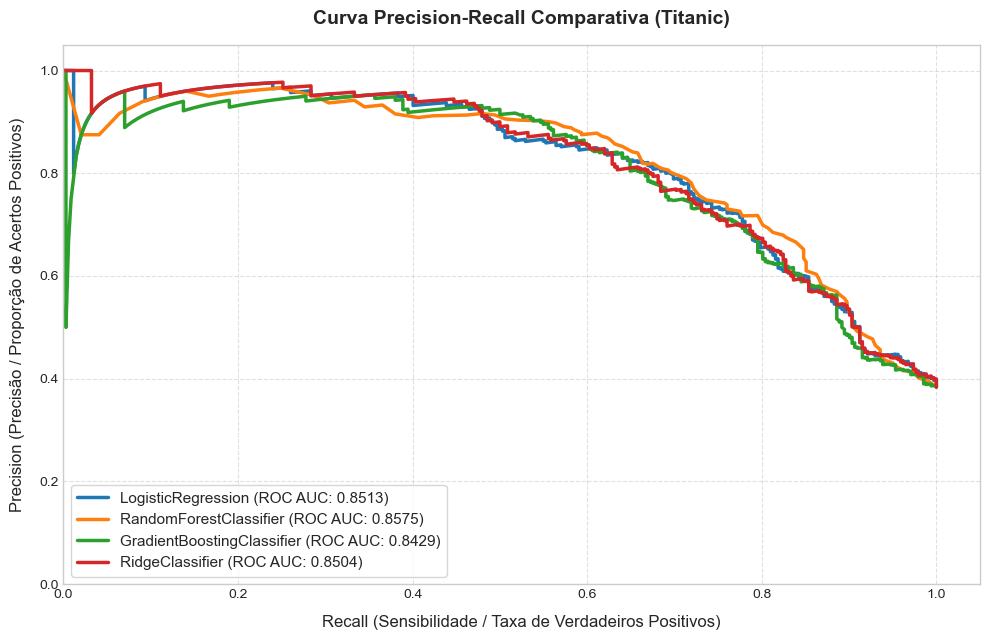

In [ ]:
import matplotlib.pyplot as plt

# ----------------------------------------------------
# GRÁFICO 1: Curva Precision-Recall (Todos os Modelos)
# ----------------------------------------------------
plt.figure(figsize=(10, 6.5))

for modelo in modelos_dados:
    # Extrai a precisão e recall calculados no seu loop
    precisions, recalls, _ = modelo['precision_recall_curve']
    
    # Plota a linha de cada modelo incluindo o ROC AUC na legenda para contexto
    plt.plot(recalls, precisions, label=f"{modelo['nome_modelo']} (ROC AUC: {modelo['roc_auc_score']:.4f})", linewidth=2.5)

plt.xlabel('Recall (Sensibilidade / Taxa de Verdadeiros Positivos)', fontsize=12, labelpad=10)
plt.ylabel('Precision (Precisão / Proporção de Acertos Positivos)', fontsize=12, labelpad=10)
plt.title('Curva Precision-Recall Comparativa (Titanic)', fontsize=14, pad=15, fontweight='bold')
plt.xlim([0.0, 1.05])
plt.ylim([0.0, 1.05])
plt.legend(loc="lower left", fontsize=11, frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



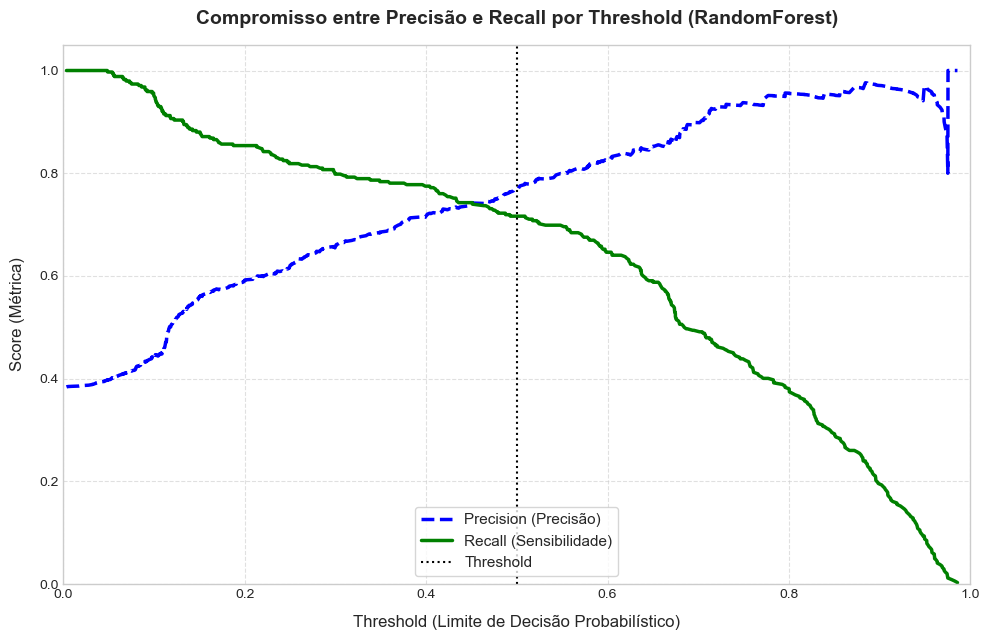

In [350]:
# ----------------------------------------------------
# GRÁFICO 2: Precisão e Recall por Threshold
# (Exemplo focado no RandomForestClassifier)
# ----------------------------------------------------
# Localiza os dados do RandomForest dentro da lista gerada pelo loop
rf_dados = next((m for m in modelos_dados if m['nome_modelo'] == 'LogisticRegression'), None)

if rf_dados:
    p, r, t = rf_dados['precision_recall_curve']
    
    plt.figure(figsize=(10, 6.5))
    # O vetor de thresholds tem exatamente 1 elemento a menos que precisão e recall
    plt.plot(t, p[:-1], 'b--', label='Precision (Precisão)', linewidth=2.5)
    plt.plot(t, r[:-1], 'g-', label='Recall (Sensibilidade)', linewidth=2.5)
    plt.vlines(0.5,0,1.1,'k','dotted',label='Threshold')
    
    plt.xlabel('Threshold (Limite de Decisão Probabilístico)', fontsize=12, labelpad=10)
    plt.ylabel('Score (Métrica)', fontsize=12, labelpad=10)
    plt.title('Compromisso entre Precisão e Recall por Threshold (RandomForest)', fontsize=14, pad=15, fontweight='bold')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.legend(loc="lower center", fontsize=11, frameon=True)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
